In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Dummy data (input → output)
input_seq = ["i love you", "hello world"]
target_seq = ["je t aime", "bonjour monde"]

In [4]:
# Tokenization
tokenizer_in = tf.keras.preprocessing.text.Tokenizer()
tokenizer_out = tf.keras.preprocessing.text.Tokenizer()

tokenizer_in.fit_on_texts(input_seq)
tokenizer_out.fit_on_texts(target_seq)

encoder_input = tokenizer_in.texts_to_sequences(input_seq)
decoder_input = tokenizer_out.texts_to_sequences(target_seq)

encoder_input = tf.keras.preprocessing.sequence.pad_sequences(encoder_input, padding='post')
decoder_input = tf.keras.preprocessing.sequence.pad_sequences(decoder_input, padding='post')

vocab_in = len(tokenizer_in.word_index) + 1
vocab_out = len(tokenizer_out.word_index) + 1

In [5]:

# Encoder
encoder_inputs = tf.keras.Input(shape=(None,))
enc_emb = tf.keras.layers.Embedding(vocab_in, 64)(encoder_inputs)
encoder_outputs, state_h, state_c = tf.keras.layers.LSTM(64, return_sequences=True, return_state=True)(enc_emb)


In [6]:

# Decoder
decoder_inputs = tf.keras.Input(shape=(None,))
dec_emb = tf.keras.layers.Embedding(vocab_out, 64)(decoder_inputs)
decoder_lstm = tf.keras.layers.LSTM(64, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

In [7]:

# Attention
attention = tf.keras.layers.Attention()
attention_output = attention([decoder_outputs, encoder_outputs])


In [8]:

# Final output
concat = tf.keras.layers.Concatenate()([decoder_outputs, attention_output])
output = tf.keras.layers.Dense(vocab_out, activation='softmax')(concat)

model = tf.keras.Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 64)  │        384 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 64)  │        384 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, None,     │     33,024 │ embedding[0][0]   │
│                     │ 64), (None, 64),  │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │     33,024 │ embedding_1[0][0… │
│                     │ 64), (None, 64),  │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, None, 64)  │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 128) │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 6)   │        774 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,590 (264.02 KB)

 Trainable params: 67,590 (264.02 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Extract attention scores manually
attention_layer = tf.keras.layers.Attention()

attn_scores = attention_layer([decoder_outputs, encoder_outputs])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step


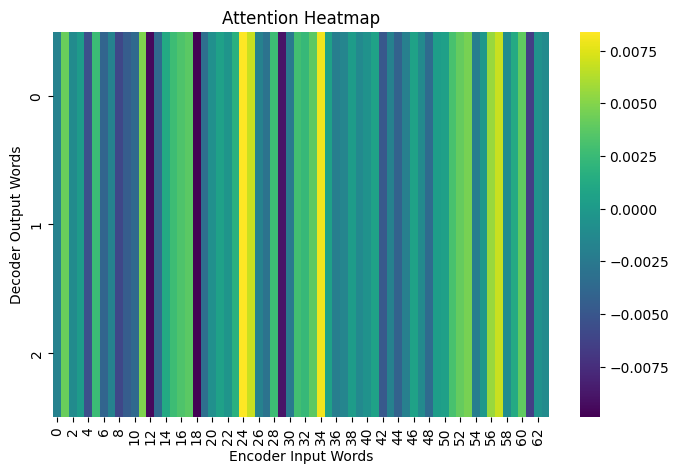

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot heatmap
plt.figure(figsize=(8,5))

# Create a model to output attention weights from the previously defined symbolic layers
# encoder_inputs, decoder_inputs, and attention_output are symbolic tensors from earlier cells
attention_model_for_prediction = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=attention_output)

# Get the concrete attention scores by predicting with the actual input sequences
# encoder_input and decoder_input are numpy arrays from earlier tokenization
attention_weights = attention_model_for_prediction.predict([encoder_input, decoder_input])

# 'attention_weights' will be a batch of attention matrices. We take the first one for plotting.
scores = attention_weights[0]

sns.heatmap(scores, cmap="viridis")
plt.xlabel("Encoder Input Words")
plt.ylabel("Decoder Output Words")
plt.title("Attention Heatmap")
plt.show()